# Benchmark Adil ARIMA dan LSTM pada IHSG

**Tujuan:** memperbaiki perbandingan yang tidak sah antara ARIMA pada 2024 dan LSTM pada 2025. Seluruh model pada notebook ini diuji pada tanggal perdagangan IHSG yang sama sepanjang 2025.

**Objek:** Indeks Harga Saham Gabungan (IHSG), simbol Yahoo Finance `^JKSE`  
**Target:** harga penutupan satu hari perdagangan ke depan  
**Validasi:** 1 Januari sampai 31 Desember 2024  
**Pengujian:** 1 Januari sampai 31 Desember 2025  
**Model:** Naive, SMA-20, ARIMA, Ridge, Random Forest, dan LSTM

> Jalankan notebook dari atas ke bawah di Kaggle. Aktifkan **Internet** pada Notebook Options agar data IHSG dapat diunduh.

## 1. Algoritma Program

1. Kunci seed, simbol IHSG, target, horizon, dan batas periode sebelum melihat hasil.
2. Muat data dari CSV Kaggle atau `yfinance`, lalu standarkan struktur OHLCV.
3. Audit tanggal, duplikasi, nilai hilang, jumlah hari perdagangan, dan cakupan 2025.
4. Bentuk fitur pada hari \(t\) dan target `Close` pada hari perdagangan berikutnya.
5. Bagi data secara kronologis: train desain sampai 2023, validasi 2024, dan uji 2025.
6. Bekukan rancangan model setelah validasi. Gabungkan train dan validasi sebagai train final.
7. Pelajari scaler hanya dari train final, tanpa memakai observasi 2025.
8. Latih enam model dengan target dan horizon sama. Jalankan LSTM pada tiga seed.
9. Selaraskan prediksi pada irisan tanggal 2025 dan satu seri aktual yang identik.
10. Tolak benchmark jika model kurang, tanggal tidak cukup, aktual berbeda, atau ada NaN.
11. Hitung MAE, RMSE, MAPE, waktu komputasi, dan stabilitas antarseed.
12. Susun Matriks Kontrol, Benchmark Card, grafik, dan laporan pertanggungjawaban.


In [1]:
import pandas as pd

algorithm_steps = pd.DataFrame({
    "Tahap": range(1, 11),
    "Proses": [
        "Kunci protokol", "Unduh dan audit data", "Bentuk fitur tanpa leakage",
        "Split kronologis", "Normalisasi dari train", "Latih 6 model",
        "Alignment tanggal", "Audit integritas", "Hitung metrik", "Benchmark Card"
    ],
    "Output": [
        "Konfigurasi", "Tabel kualitas data", "Tabel fitur", "Tabel split",
        "Statistik scaler", "Prediksi per model", "Tabel aligned", "Status audit",
        "Tabel metrik", "Peringkat dan grafik"
    ]
})
display(algorithm_steps)

,Tahap,Proses,Output
0,1,Kunci protokol,Konfigurasi
1,2,Unduh dan audit data,Tabel kualitas data
2,3,Bentuk fitur tanpa leakage,Tabel fitur
3,4,Split kronologis,Tabel split
4,5,Normalisasi dari train,Statistik scaler
5,6,Latih 6 model,Prediksi per model
6,7,Alignment tanggal,Tabel aligned
7,8,Audit integritas,Status audit
8,9,Hitung metrik,Tabel metrik
9,10,Benchmark Card,Peringkat dan grafik


## 2. Pseudocode Program

```text
MULAI
  tetapkan SEED, TICKER, TARGET, HORIZON, TRAIN_END, VALIDASI, TEST
  unduh data IHSG
  validasi tanggal unik, urutan waktu, nilai hilang, dan jumlah observasi

  buat target = Close pada hari perdagangan berikutnya
  buat fitur lag hanya dari t dan masa lalu
  bagi data secara kronologis

  UNTUK setiap model:
      latih hanya dengan data sebelum periode uji
      catat waktu komputasi
      prediksi target satu hari ke depan pada 2025
      simpan Date, Actual, Prediction, Model, Seed
  SELESAI

  inner join seluruh prediksi berdasarkan Date
  JIKA aktual hilang ATAU berbeda antar-model ATAU jumlah baris berbeda:
      HENTIKAN benchmark dan tampilkan pesan audit
  SELAIN ITU:
      hitung MAE, RMSE, MAPE, waktu, dan stabilitas
      urutkan model berdasarkan RMSE terendah
      tampilkan Benchmark Card dan visual diagnostik
  AKHIR JIKA
SELESAI
```

In [2]:
checks = pd.DataFrame([
    ["Kesamaan periode uji", "Tanggal perdagangan 2025 yang sama", "Wajib"],
    ["Kesamaan target", "Close(t+1)", "Wajib"],
    ["Kesamaan horizon", "1 hari perdagangan", "Wajib"],
    ["Look-ahead bias", "Fitur t atau lebih lama untuk target t+1", "Nol toleransi"],
    ["Normalisasi", "Scaler fit pada train final sebelum 2025", "Wajib"],
    ["Kelengkapan uji", ">=180 observasi dan cakupan >=95%", "Wajib"],
    ["Alignment", "Irisan tanggal dan aktual identik", "Wajib"],
    ["Kelengkapan model", "Enam model harus menghasilkan prediksi", "Wajib"],
    ["Seed", "LSTM dijalankan beberapa seed", "Minimal 3"],
])
display(checks.style.set_caption("Checklist Pseudocode dan Integritas"))


,0,1,2
0,Kesamaan periode uji,Tanggal perdagangan 2025 yang sama,Wajib
1,Kesamaan target,Close(t+1),Wajib
2,Kesamaan horizon,1 hari perdagangan,Wajib
3,Look-ahead bias,Fitur t atau lebih lama untuk target t+1,Nol toleransi
4,Normalisasi,Scaler fit pada train final sebelum 2025,Wajib
5,Kelengkapan uji,>=180 observasi dan cakupan >=95%,Wajib
6,Alignment,Irisan tanggal dan aktual identik,Wajib
7,Kelengkapan model,Enam model harus menghasilkan prediksi,Wajib
8,Seed,LSTM dijalankan beberapa seed,Minimal 3


## 3. Instalasi dan Konfigurasi

Tahap ini memasang paket, mengunci seed, dan menampilkan konfigurasi eksperimen. Jika TensorFlow tidak tersedia, Kaggle akan memasangnya melalui pip.

In [3]:
!pip -q install "yfinance>=0.2.54"

import os, sys, glob, time, random, warnings, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

try:
    import yfinance as yf
except ImportError as exc:
    raise RuntimeError("yfinance gagal dipasang. Aktifkan Internet Kaggle lalu jalankan ulang.") from exc

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

BASE_SEED = 42
LSTM_SEEDS = [42, 123, 2025]
TICKER = "^JKSE"
START_DATE = "2015-01-01"
DOWNLOAD_END_EXCLUSIVE = "2026-01-10"
TRAIN_END = "2023-12-31"
VAL_START, VAL_END = "2024-01-01", "2024-12-31"
TEST_START, TEST_END = "2025-01-01", "2025-12-31"
MIN_TEST_ROWS = 180
MIN_LAST_TEST_DATE = "2025-12-15"
LOOKBACK = 20
HORIZON = 1
CSV_PATH = ""  # Opsional, contoh: /kaggle/input/ihsg-data/ihsg.csv

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
tf.random.set_seed(BASE_SEED)

config = pd.DataFrame({
    "Parameter": [
        "Ticker", "Rentang unduhan", "Train desain", "Validasi",
        "Train final", "Uji bersama", "Target", "Horizon",
        "Minimum observasi uji", "Seed LSTM"
    ],
    "Nilai": [
        TICKER, f"{START_DATE} s.d. akhir 2025", f"s.d. {TRAIN_END}",
        f"{VAL_START} s.d. {VAL_END}", "Train desain + validasi 2024",
        f"{TEST_START} s.d. {TEST_END}", "Close(t+1)",
        "1 hari perdagangan", MIN_TEST_ROWS, str(LSTM_SEEDS)
    ]
})
display(config.style.set_caption("Konfigurasi Eksperimen Terkunci"))


,Parameter,Nilai
0,Ticker,^JKSE
1,Rentang unduhan,2015-01-01 s.d. akhir 2025
2,Train desain,s.d. 2023-12-31
3,Validasi,2024-01-01 s.d. 2024-12-31
4,Train final,Train desain + validasi 2024
5,Uji bersama,2025-01-01 s.d. 2025-12-31
6,Target,Close(t+1)
7,Horizon,1 hari perdagangan
8,Minimum observasi uji,180
9,Seed LSTM,"[42, 123, 2025]"


## 4. Akuisisi dan Audit Data IHSG

Kode memprioritaskan CSV yang ditentukan pengguna, lalu mencari CSV OHLCV pada
Kaggle Input, dan terakhir mengunduh `^JKSE` melalui `yfinance`. Batas `end`
pada `yfinance` bersifat eksklusif. Karena itu, kode meminta data sampai awal
2026 agar seluruh hari perdagangan 2025 tercakup.

Kelengkapan tahun uji tidak dinilai dengan menuntut transaksi tepat pada
31 Desember. Bursa tutup pada akhir pekan dan hari libur. Audit memakai jumlah
observasi perdagangan, cakupan tanggal akhir, serta keberadaan data sepanjang
2025. Kegagalan akan menampilkan diagnosis dan tindakan yang spesifik.


,Indikator,Nilai
0,Sumber,Yahoo Finance melalui yfinance (^JKSE)
1,Tanggal awal,2015-01-02
2,Tanggal akhir,2026-01-09
3,Jumlah baris,2667
4,Duplikasi tanggal,0
5,Close hilang,0
6,Observasi uji 2025,236
7,Tanggal uji pertama,2025-01-02
8,Tanggal uji terakhir,2025-12-30
9,Urutan naik,True


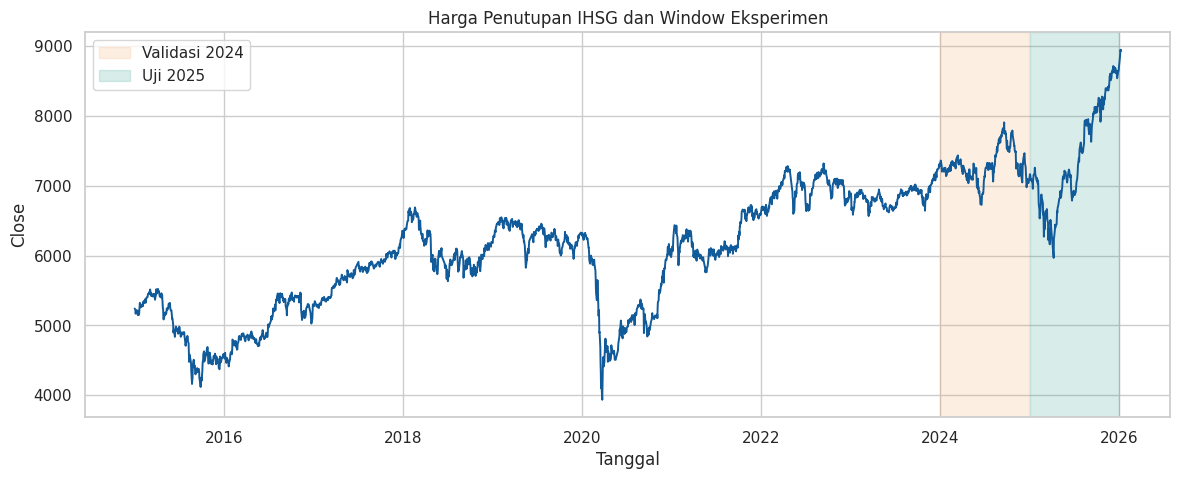

In [4]:
def standardize_ohlcv(raw):
    """Menyeragamkan keluaran yfinance atau CSV menjadi tabel OHLCV."""
    data = raw.copy()

    if isinstance(data.columns, pd.MultiIndex):
        level0 = [str(x) for x in data.columns.get_level_values(0)]
        if {"Open", "High", "Low", "Close"}.issubset(set(level0)):
            data.columns = data.columns.get_level_values(0)
        else:
            data.columns = data.columns.get_level_values(-1)

    data.columns = [
        str(c).strip().lower().replace(" ", "_").replace(".", "_")
        for c in data.columns
    ]
    date_col = next(
        (c for c in ["date", "datetime", "tanggal", "time"] if c in data.columns),
        None,
    )
    if date_col:
        data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
        data = data.set_index(date_col)
    else:
        data.index = pd.to_datetime(data.index, errors="coerce")

    aliases = {
        "open": ["open", "pembukaan"],
        "high": ["high", "tertinggi"],
        "low": ["low", "terendah"],
        "close": ["close", "adj_close", "adjusted_close", "penutupan"],
        "volume": ["volume", "vol"],
    }
    selected = {}
    for target, candidates in aliases.items():
        found = next((c for c in candidates if c in data.columns), None)
        if found is not None:
            selected[target.title()] = pd.to_numeric(data[found], errors="coerce")

    missing = [c for c in ["Open", "High", "Low", "Close"] if c not in selected]
    if missing:
        raise ValueError(
            f"Kolom harga wajib tidak ditemukan: {missing}. "
            "CSV minimal memerlukan Date, Open, High, Low, dan Close."
        )
    if "Volume" not in selected:
        selected["Volume"] = pd.Series(0.0, index=data.index)

    clean = pd.DataFrame(selected)
    clean.index = pd.to_datetime(clean.index, errors="coerce")
    if getattr(clean.index, "tz", None) is not None:
        clean.index = clean.index.tz_localize(None)
    clean = clean.loc[clean.index.notna()].sort_index()
    clean = clean.loc[~clean.index.duplicated(keep="last")]
    clean = clean.dropna(subset=["Open", "High", "Low", "Close"])
    clean["Volume"] = clean["Volume"].fillna(0.0)
    clean.index.name = "Date"
    return clean


def find_valid_csv():
    candidates = [CSV_PATH] if CSV_PATH else []
    candidates += sorted(glob.glob("/kaggle/input/**/*.csv", recursive=True))
    rejected = []
    for candidate in candidates:
        try:
            probe = standardize_ohlcv(pd.read_csv(candidate))
            if len(probe) >= 500:
                return candidate, rejected
            rejected.append(f"{candidate}: hanya {len(probe)} baris")
        except Exception as exc:
            rejected.append(f"{candidate}: {type(exc).__name__}")
    return None, rejected


def load_ihsg():
    csv_file, rejected = find_valid_csv()
    if csv_file:
        return standardize_ohlcv(pd.read_csv(csv_file)), f"CSV Kaggle: {csv_file}", rejected

    try:
        downloaded = yf.download(
            TICKER,
            start=START_DATE,
            end=DOWNLOAD_END_EXCLUSIVE,
            auto_adjust=False,
            progress=False,
            threads=False,
            timeout=30,
        )
    except Exception as exc:
        raise RuntimeError(
            "Unduhan IHSG gagal. Aktifkan Internet pada Kaggle atau tambahkan "
            "CSV OHLCV melalui Add Input dan isi CSV_PATH."
        ) from exc

    if downloaded is None or downloaded.empty:
        raise RuntimeError(
            "Yahoo Finance mengembalikan data kosong. Aktifkan Internet Kaggle, "
            "jalankan ulang, atau gunakan CSV IHSG sebagai sumber cadangan."
        )
    return standardize_ohlcv(downloaded), "Yahoo Finance melalui yfinance (^JKSE)", rejected


prices, data_source, rejected_csv = load_ihsg()
df = prices.reset_index()
test_rows = df[df["Date"].between(TEST_START, TEST_END)].copy()

quality = pd.DataFrame({
    "Indikator": [
        "Sumber", "Tanggal awal", "Tanggal akhir", "Jumlah baris",
        "Duplikasi tanggal", "Close hilang", "Observasi uji 2025",
        "Tanggal uji pertama", "Tanggal uji terakhir", "Urutan naik"
    ],
    "Nilai": [
        data_source, df.Date.min().date(), df.Date.max().date(), len(df),
        int(df.Date.duplicated().sum()), int(df.Close.isna().sum()), len(test_rows),
        test_rows.Date.min().date() if len(test_rows) else "tidak ada",
        test_rows.Date.max().date() if len(test_rows) else "tidak ada",
        bool(df.Date.is_monotonic_increasing)
    ]
})
display(quality.style.set_caption("Audit Kualitas Data IHSG"))

problems = []
if len(df) < 1200:
    problems.append(f"data historis hanya {len(df)} baris, minimum 1.200")
if len(test_rows) < MIN_TEST_ROWS:
    problems.append(
        f"data uji 2025 hanya {len(test_rows)} observasi, minimum {MIN_TEST_ROWS}"
    )
if len(test_rows) and test_rows.Date.max() < pd.Timestamp(MIN_LAST_TEST_DATE):
    problems.append(
        f"tanggal terakhir uji {test_rows.Date.max().date()} terlalu dini"
    )
if not df.Date.is_monotonic_increasing or df.Date.duplicated().any():
    problems.append("tanggal belum unik dan terurut")

if problems:
    diagnosis = pd.DataFrame({
        "Masalah": problems,
        "Tindakan": [
            "Periksa Internet Kaggle atau unggah CSV IHSG yang mencakup 2015 sampai 2025."
        ] * len(problems)
    })
    display(diagnosis.style.set_caption("Diagnosis Akuisisi Data"))
    raise RuntimeError("Audit data gagal: " + "; ".join(problems))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.Date, df.Close, color="#125B9A", lw=1.4)
ax.axvspan(pd.Timestamp(VAL_START), pd.Timestamp(VAL_END),
           color="#F4A261", alpha=.18, label="Validasi 2024")
ax.axvspan(pd.Timestamp(TEST_START), pd.Timestamp(TEST_END),
           color="#2A9D8F", alpha=.18, label="Uji 2025")
ax.set(title="Harga Penutupan IHSG dan Window Eksperimen",
       xlabel="Tanggal", ylabel="Close")
ax.legend()
plt.show()


## 5. Rekayasa Fitur dan Pencegahan Leakage

Target pada baris tanggal `t` adalah penutupan hari perdagangan berikutnya. Semua fitur hanya memakai informasi yang tersedia pada atau sebelum `t`. Prediksi kemudian diberi `TargetDate`, yaitu tanggal aktual yang diramalkan.

,Date,TargetDate,Close,MA20,Target
0,2015-01-30 00:00:00,2015-02-02 00:00:00,5289.403809,5219.619019,5276.235840
1,2015-02-02 00:00:00,2015-02-03 00:00:00,5276.235840,5222.431055,5291.717773
2,2015-02-03 00:00:00,2015-02-04 00:00:00,5291.717773,5228.563940,5315.284180
3,2015-02-04 00:00:00,2015-02-05 00:00:00,5315.284180,5233.972241,5279.895020
4,2015-02-05 00:00:00,2015-02-06 00:00:00,5279.895020,5237.375586,5342.515137
5,2015-02-06 00:00:00,2015-02-09 00:00:00,5342.515137,5243.668091,5348.470215
6,2015-02-09 00:00:00,2015-02-10 00:00:00,5348.470215,5251.694946,5321.474121
7,2015-02-10 00:00:00,2015-02-11 00:00:00,5321.474121,5257.050708,5336.519043


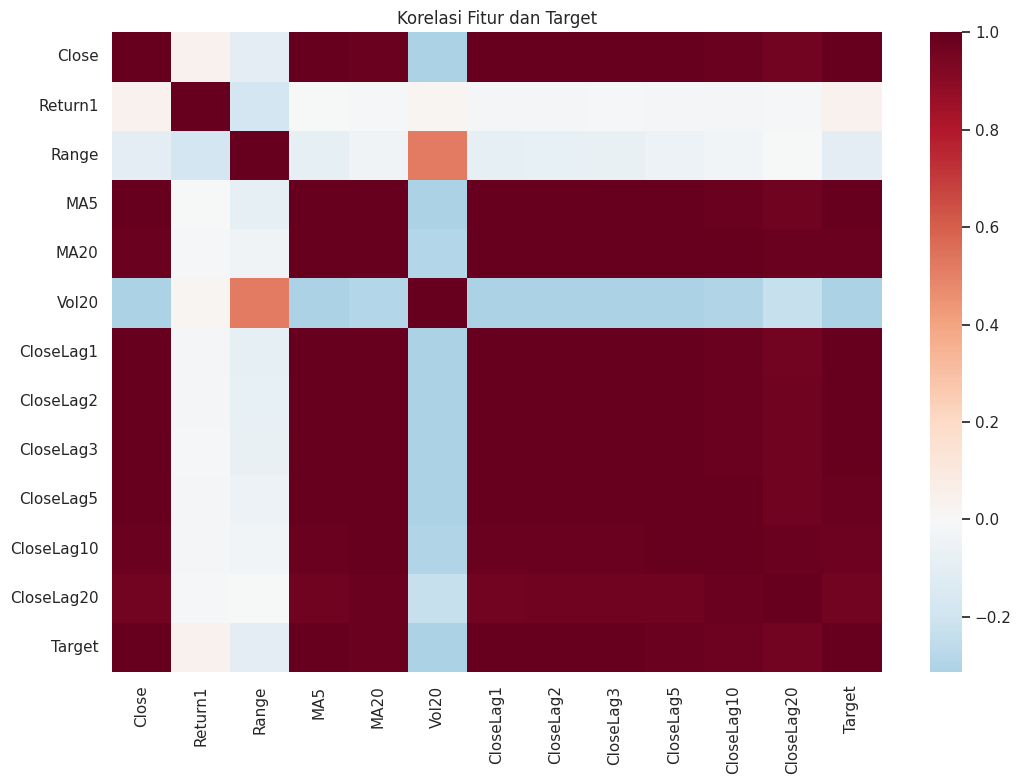

In [5]:
feat = df[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()
feat["Return1"] = feat["Close"].pct_change()
feat["Range"] = (feat["High"] - feat["Low"]) / feat["Close"]
feat["MA5"] = feat["Close"].rolling(5).mean()
feat["MA20"] = feat["Close"].rolling(20).mean()
feat["Vol20"] = feat["Return1"].rolling(20).std()
for lag in [1, 2, 3, 5, 10, 20]:
    feat[f"CloseLag{lag}"] = feat["Close"].shift(lag)
feat["Target"] = feat["Close"].shift(-HORIZON)
feat["TargetDate"] = feat["Date"].shift(-HORIZON)
feat = feat.dropna().reset_index(drop=True)

feature_cols = ["Close", "Return1", "Range", "MA5", "MA20", "Vol20", "CloseLag1", "CloseLag2", "CloseLag3", "CloseLag5", "CloseLag10", "CloseLag20"]

# Audit logika waktu: tanggal fitur wajib lebih awal daripada tanggal target.
assert (feat["Date"] < feat["TargetDate"]).all(), "BUG: target tidak berada setelah fitur."
assert np.isfinite(feat[feature_cols + ["Target"]]).all().all(), "BUG: fitur mengandung NaN/inf."

display(feat[["Date", "TargetDate", "Close", "MA20", "Target"]].head(8).style.set_caption("Contoh Alignment Fitur dan Target"))

corr = feat[feature_cols + ["Target"]].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=False)
plt.title("Korelasi Fitur dan Target"); plt.tight_layout(); plt.show()

## 6. Split Kronologis dan Matriks Kontrol

Tanggal pemisahan mengikuti `TargetDate`, bukan tanggal fitur. Keputusan ini memastikan semua model dinilai berdasarkan tanggal aktual yang diprediksi.

In [6]:
train = feat[feat.TargetDate <= TRAIN_END].copy()
val = feat[feat.TargetDate.between(VAL_START, VAL_END)].copy()
test = feat[feat.TargetDate.between(TEST_START, TEST_END)].copy()

assert len(train) > 500, "BUG: observasi train tidak memadai."
assert len(val) > 150, "BUG: observasi validasi tidak memadai."
assert len(test) >= MIN_TEST_ROWS, "BUG: observasi uji 2025 tidak memadai."
assert train.TargetDate.max() < val.TargetDate.min() < test.TargetDate.min(), (
    "BUG: split kronologis tumpang tindih."
)

split_table = pd.DataFrame({
    "Split": ["Train desain", "Validasi", "Uji final"],
    "Awal target": [train.TargetDate.min(), val.TargetDate.min(), test.TargetDate.min()],
    "Akhir target": [train.TargetDate.max(), val.TargetDate.max(), test.TargetDate.max()],
    "Observasi": [len(train), len(val), len(test)]
})
display(split_table.style.set_caption("Pembagian Data Kronologis"))

matrix_control = pd.DataFrame({
    "Model": ["Naive", "SMA-20", "ARIMA", "Ridge", "Random Forest", "LSTM"],
    "Train final": [
        "Riwayat sebelum tiap target", "Riwayat sebelum tiap target",
        "s.d. 2024 + update aktual", "s.d. 2024", "s.d. 2024", "s.d. 2024"
    ],
    "Validasi desain": ["2024"] * 6,
    "Test": ["Tanggal perdagangan 2025 yang sama"] * 6,
    "Target": ["Close t+1"] * 6,
    "Horizon": [1] * 6,
    "Normalisasi": [
        "Tidak", "Tidak", "Tidak", "StandardScaler train final",
        "Tidak", "MinMaxScaler train final"
    ],
    "Seed": ["NA", "NA", "NA", "42", "42", str(LSTM_SEEDS)],
    "Status awal": ["Sesuai protokol"] * 6
})
display(matrix_control.style.set_caption("Matriks Kontrol Sebelum Pelatihan"))


,Split,Awal target,Akhir target,Observasi
0,Train desain,2015-02-02 00:00:00,2023-12-29 00:00:00,2167
1,Validasi,2024-01-02 00:00:00,2024-12-30 00:00:00,237
2,Uji final,2025-01-02 00:00:00,2025-12-30 00:00:00,236


,Model,Train final,Validasi desain,Test,Target,Horizon,Normalisasi,Seed,Status awal
0,Naive,Riwayat sebelum tiap target,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,NA,Sesuai protokol
1,SMA-20,Riwayat sebelum tiap target,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,NA,Sesuai protokol
2,ARIMA,s.d. 2024 + update aktual,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,NA,Sesuai protokol
3,Ridge,s.d. 2024,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,StandardScaler train final,42,Sesuai protokol
4,Random Forest,s.d. 2024,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,42,Sesuai protokol
5,LSTM,s.d. 2024,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,MinMaxScaler train final,"[42, 123, 2025]",Sesuai protokol


## 7. Fungsi Evaluasi, Penyimpanan, dan Alignment

Fungsi berikut menjadi pusat kontrol. Setiap hasil wajib mempunyai empat kolom: tanggal target, aktual, prediksi, dan model. Alignment menggunakan irisan tanggal yang sama. Benchmark akan dihentikan jika data aktual berbeda antar-model.

In [7]:
results, timing = [], []

def add_result(model, dates, actual, pred, seconds, seed=None):
    out = pd.DataFrame({
        "Date": pd.to_datetime(dates), "Actual": np.asarray(actual, float),
        "Prediction": np.asarray(pred, float), "Model": model,
        "Seed": "NA" if seed is None else int(seed)
    })
    if out[["Actual", "Prediction"]].isna().any().any():
        raise ValueError(f"BUG {model}: prediksi atau aktual mengandung NaN.")
    if out.Date.duplicated().any():
        raise ValueError(f"BUG {model}: tanggal prediksi duplikat.")
    results.append(out)
    timing.append({"Model": model, "Seed": out.Seed.iloc[0], "Seconds": seconds})
    return out

def metric_frame(long_df):
    rows = []
    for (model, seed), g in long_df.groupby(["Model", "Seed"]):
        err = g.Actual - g.Prediction
        rows.append({"Model": model, "Seed": seed, "N": len(g),
                     "MAE": np.abs(err).mean(), "RMSE": np.sqrt(np.mean(err**2)),
                     "MAPE_pct": np.mean(np.abs(err / g.Actual)) * 100})
    return pd.DataFrame(rows)

schema = pd.DataFrame({"Kolom wajib": ["Date", "Actual", "Prediction", "Model", "Seed"],
                       "Aturan": ["unik dan sama", "identik antar-model", "numerik tanpa NaN", "label unik", "dicatat"]})
display(schema.style.set_caption("Kontrak Data Hasil Model"))

,Kolom wajib,Aturan
0,Date,unik dan sama
1,Actual,identik antar-model
2,Prediction,numerik tanpa NaN
3,Model,label unik
4,Seed,dicatat


## 8. Model Baseline: Naive dan SMA-20

Naive memakai harga penutupan terakhir. SMA-20 memakai rata-rata 20 penutupan terakhir. Keduanya wajib ada agar model kompleks tidak menang hanya karena benchmark terlalu lemah.

,Model,Seed,N,MAE,RMSE,MAPE_pct
0,Naive,NA,236,62.30,85.40,0.866
1,SMA-20,NA,236,179.32,217.35,2.470


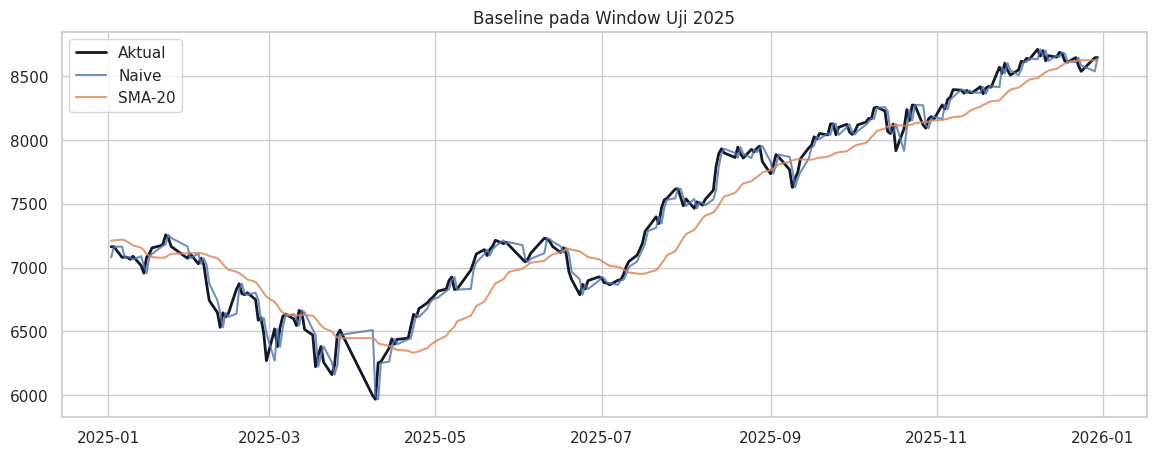

In [8]:
t0 = time.perf_counter()
naive_pred = test["Close"].to_numpy()
naive_out = add_result("Naive", test.TargetDate, test.Target, naive_pred, time.perf_counter()-t0)

t0 = time.perf_counter()
sma_pred = test["MA20"].to_numpy()
sma_out = add_result("SMA-20", test.TargetDate, test.Target, sma_pred, time.perf_counter()-t0)

base_metrics = metric_frame(pd.concat([naive_out, sma_out], ignore_index=True))
display(base_metrics.style.format({"MAE":"{:,.2f}", "RMSE":"{:,.2f}", "MAPE_pct":"{:.3f}"}).set_caption("Output Tahap Baseline"))

plt.figure(figsize=(14, 5))
plt.plot(naive_out.Date, naive_out.Actual, label="Aktual", color="#111827", lw=2)
plt.plot(naive_out.Date, naive_out.Prediction, label="Naive", alpha=.8)
plt.plot(sma_out.Date, sma_out.Prediction, label="SMA-20", alpha=.8)
plt.title("Baseline pada Window Uji 2025"); plt.legend(); plt.show()

## 9. ARIMA dengan Update Satu Langkah

ARIMA dilatih memakai harga sampai akhir 2024. Pada setiap tanggal uji, model meramalkan satu langkah, lalu menerima nilai aktual terbaru. Proses internal memakai indeks posisi numerik karena kalender perdagangan memiliki akhir pekan dan hari libur sehingga `DatetimeIndex` tidak berfrekuensi tetap. Tanggal perdagangan tetap disimpan terpisah untuk audit dan alignment. Pendekatan ini mempertahankan horizon satu hari tanpa memaksakan frekuensi kalender yang keliru.

,Model,Seed,N,MAE,RMSE,MAPE_pct
0,ARIMA,NA,236,62.20,84.70,0.864


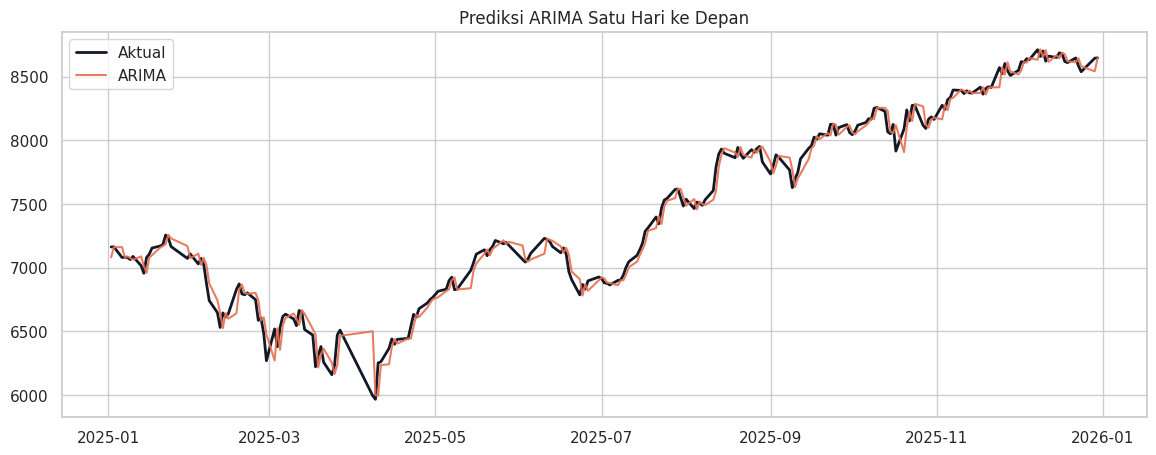

In [9]:
series_pretest = (
    df.loc[df.Date < pd.Timestamp(TEST_START), ["Date", "Close"]]
    .dropna()
    .drop_duplicates("Date", keep="last")
    .sort_values("Date")
)
actual_2025 = (
    df.loc[df.Date.between(TEST_START, TEST_END), ["Date", "Close"]]
    .dropna()
    .drop_duplicates("Date", keep="last")
    .set_index("Date")["Close"]
    .sort_index()
    .reindex(pd.DatetimeIndex(test.TargetDate))
    .dropna()
)

if len(actual_2025) != len(test):
    missing_dates = pd.DatetimeIndex(test.TargetDate).difference(actual_2025.index)
    raise ValueError(
        "BUG ARIMA: data aktual tidak lengkap pada tanggal target bersama. "
        f"Tanggal hilang: {missing_dates[:10].strftime('%Y-%m-%d').tolist()}"
    )
if not actual_2025.index.equals(pd.DatetimeIndex(test.TargetDate)):
    raise ValueError("BUG ARIMA: urutan tanggal aktual tidak sama dengan test.TargetDate.")

# Statsmodels tidak boleh menerima DatetimeIndex hari bursa tanpa frekuensi tetap
# pada append(). Gunakan ndarray untuk state model dan simpan tanggal secara terpisah.
arima_history = series_pretest["Close"].to_numpy(dtype="float64")
if len(arima_history) < 100:
    raise ValueError("BUG ARIMA: riwayat sebelum periode uji terlalu pendek.")

arima_start = time.perf_counter()
arima_fit = ARIMA(
    arima_history,
    order=(5, 1, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()
arima_pred = []
for date, actual in actual_2025.items():
    forecast = float(np.asarray(arima_fit.forecast(steps=1)).reshape(-1)[0])
    if not np.isfinite(forecast):
        raise FloatingPointError(f"BUG ARIMA: prediksi nonfinite pada {date:%Y-%m-%d}.")
    arima_pred.append(forecast)
    arima_fit = arima_fit.append(
        np.asarray([actual], dtype="float64"),
        refit=False,
    )
arima_seconds = time.perf_counter() - arima_start
if len(arima_pred) != len(actual_2025):
    raise RuntimeError("BUG ARIMA: jumlah prediksi tidak sama dengan jumlah aktual.")
arima_out = add_result("ARIMA", actual_2025.index, actual_2025.values, arima_pred, arima_seconds)

display(metric_frame(arima_out).style.format({"MAE":"{:,.2f}", "RMSE":"{:,.2f}", "MAPE_pct":"{:.3f}"}).set_caption("Output Tahap ARIMA"))
plt.figure(figsize=(14, 5))
plt.plot(arima_out.Date, arima_out.Actual, label="Aktual", color="#111827", lw=2)
plt.plot(arima_out.Date, arima_out.Prediction, label="ARIMA", color="#E76F51", alpha=.9)
plt.title("Prediksi ARIMA Satu Hari ke Depan"); plt.legend(); plt.show()

## 10. Ridge dan Random Forest

Kedua model memakai fitur dan tanggal yang sama. `StandardScaler` untuk Ridge dipelajari dari gabungan data sebelum 2025 saja. Random Forest tidak memerlukan normalisasi. Tidak ada pengacakan pembagian waktu.

,Model,Seed,N,MAE,RMSE,MAPE_pct
0,Random Forest,42,236,233.32,357.05,2.902
1,Ridge,42,236,63.27,85.12,0.879


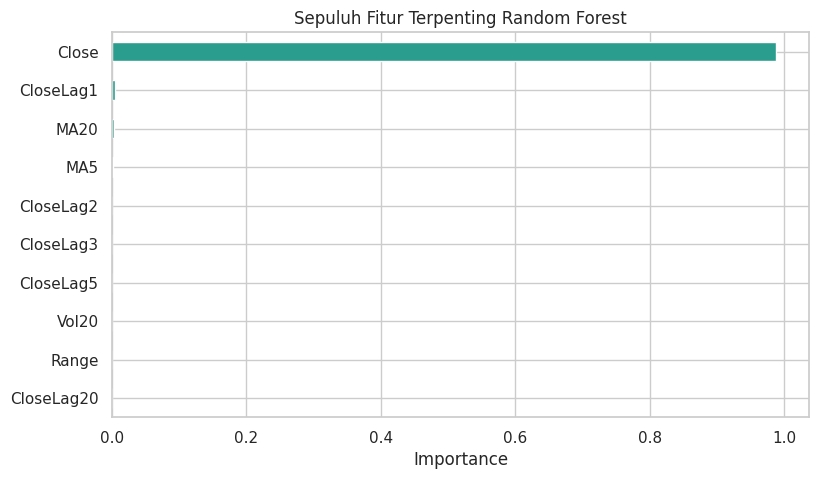

In [10]:
pretest = pd.concat([train, val], ignore_index=True)
X_train, y_train = pretest[feature_cols], pretest.Target
X_test, y_test = test[feature_cols], test.Target

scaler = StandardScaler().fit(X_train)
X_train_sc, X_test_sc = scaler.transform(X_train), scaler.transform(X_test)

t0 = time.perf_counter()
ridge = Ridge(alpha=1.0).fit(X_train_sc, y_train)
ridge_pred = ridge.predict(X_test_sc)
ridge_out = add_result("Ridge", test.TargetDate, y_test, ridge_pred, time.perf_counter()-t0, BASE_SEED)

t0 = time.perf_counter()
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=BASE_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_out = add_result("Random Forest", test.TargetDate, y_test, rf_pred, time.perf_counter()-t0, BASE_SEED)

ml_metrics = metric_frame(pd.concat([ridge_out, rf_out], ignore_index=True))
display(ml_metrics.style.format({"MAE":"{:,.2f}", "RMSE":"{:,.2f}", "MAPE_pct":"{:.3f}"}).set_caption("Output Tahap Machine Learning"))

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values().tail(10)
plt.figure(figsize=(9, 5)); imp.plot.barh(color="#2A9D8F")
plt.title("Sepuluh Fitur Terpenting Random Forest"); plt.xlabel("Importance"); plt.show()

## 11. LSTM dengan Beberapa Seed

Normalisasi LSTM dipelajari hanya dari data sebelum 2025. Tiga seed dipakai agar stabilitas dapat dihitung. Untuk analisis lebih kuat, ubah `LSTM_SEEDS` menjadi sedikitnya lima nilai jika sumber daya Kaggle mencukupi.

I0000 00:00:1785464946.909423      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


,Model,Seed,N,MAE,RMSE,MAPE_pct
0,LSTM,42,236,131.62,163.19,1.748
1,LSTM,123,236,133.69,166.71,1.764
2,LSTM,2025,236,118.72,148.92,1.570


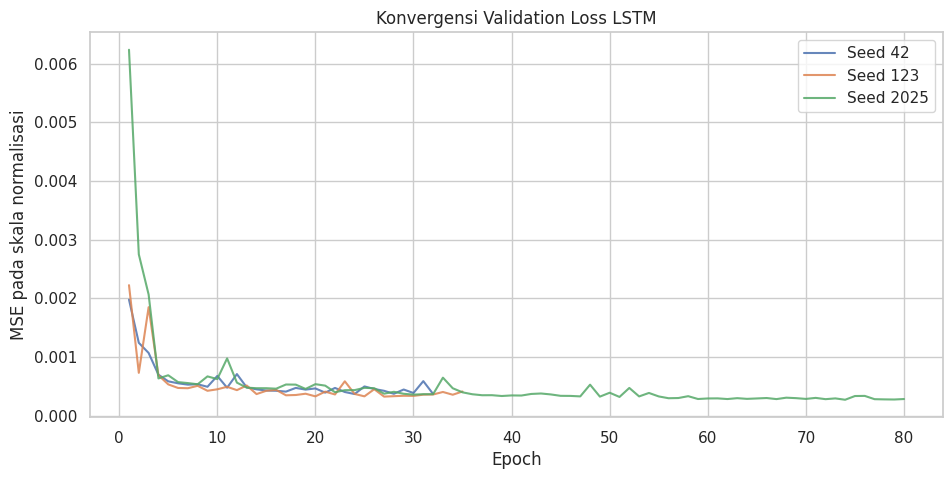

In [11]:
def make_sequences(values, lookback):
    X, y, dates = [], [], []
    for i in range(lookback, len(values)):
        X.append(values.iloc[i-lookback:i, 0].to_numpy())
        y.append(values.iloc[i, 0])
        dates.append(values.index[i])
    return np.asarray(X)[..., None], np.asarray(y), pd.DatetimeIndex(dates)


close_all = df.set_index("Date")[["Close"]].copy()
pretest_close = close_all.loc[close_all.index < pd.Timestamp(TEST_START)]
scaler_lstm = MinMaxScaler().fit(pretest_close)
scaled_all = pd.DataFrame(
    scaler_lstm.transform(close_all),
    index=close_all.index,
    columns=["Close"]
)
X_seq, y_seq, date_seq = make_sequences(scaled_all, LOOKBACK)
train_mask = date_seq < pd.Timestamp(TEST_START)
test_mask = (
    (date_seq >= pd.Timestamp(TEST_START))
    & (date_seq <= pd.Timestamp(TEST_END))
)
X_lstm_train, y_lstm_train = X_seq[train_mask], y_seq[train_mask]
X_lstm_test = X_seq[test_mask]
y_lstm_test = y_seq[test_mask]
dates_lstm = date_seq[test_mask]

assert len(dates_lstm) >= MIN_TEST_ROWS, "BUG: sequence LSTM 2025 tidak lengkap."
assert dates_lstm.is_monotonic_increasing, "BUG: tanggal sequence LSTM tidak terurut."

histories = []
for seed in LSTM_SEEDS:
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    model = Sequential([
        Input(shape=(LOOKBACK, 1)),
        LSTM(32),
        Dropout(0.20, seed=seed),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    stop = EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    )
    t0 = time.perf_counter()
    hist = model.fit(
        X_lstm_train, y_lstm_train,
        validation_split=.15,
        epochs=80,
        batch_size=32,
        shuffle=False,
        callbacks=[stop],
        verbose=0
    )
    seconds = time.perf_counter() - t0
    pred_scaled = model.predict(X_lstm_test, verbose=0)
    pred = scaler_lstm.inverse_transform(pred_scaled).ravel()
    actual = scaler_lstm.inverse_transform(
        y_lstm_test.reshape(-1, 1)
    ).ravel()
    add_result("LSTM", dates_lstm, actual, pred, seconds, seed)
    histories.append(pd.DataFrame({
        "Epoch": range(1, len(hist.history["loss"]) + 1),
        "TrainLoss": hist.history["loss"],
        "ValLoss": hist.history["val_loss"],
        "Seed": seed
    }))

lstm_long = pd.concat(
    [r for r in results if r.Model.iloc[0] == "LSTM"],
    ignore_index=True
)
lstm_metrics = metric_frame(lstm_long)
display(
    lstm_metrics.style.format({
        "MAE": "{:,.2f}", "RMSE": "{:,.2f}", "MAPE_pct": "{:.3f}"
    }).set_caption("Output LSTM per Seed")
)

history_df = pd.concat(histories, ignore_index=True)
plt.figure(figsize=(11, 5))
for seed, group in history_df.groupby("Seed"):
    plt.plot(group.Epoch, group.ValLoss, label=f"Seed {seed}", alpha=.85)
plt.title("Konvergensi Validation Loss LSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE pada skala normalisasi")
plt.legend()
plt.show()


## 12. Alignment dan Audit Bug

Kode memakai tanggal bersama dari seluruh model. Untuk LSTM, prediksi beberapa seed dirata-ratakan lebih dahulu sebagai prediksi utama. Data aktual tidak dirata-ratakan. Sistem mengambil satu seri aktual lalu memverifikasi konsistensinya pada semua model.

In [12]:
all_long = pd.concat(results, ignore_index=True)
actual_reference = (
    test[["TargetDate", "Target"]]
    .rename(columns={"TargetDate": "Date", "Target": "Actual_ref"})
    .drop_duplicates("Date", keep="last")
    .sort_values("Date")
)

# Audit aktual dilakukan sebelum agregasi agar perbedaan antar-seed tidak tersembunyi.
raw_actual_audit = all_long.merge(
    actual_reference,
    on="Date",
    how="left",
    validate="many_to_one",
)
if raw_actual_audit["Actual_ref"].isna().any():
    bad_dates = raw_actual_audit.loc[
        raw_actual_audit["Actual_ref"].isna(), "Date"
    ].drop_duplicates().head(10)
    raise ValueError(
        "BUG alignment: terdapat tanggal prediksi di luar target resmi: "
        f"{bad_dates.dt.strftime('%Y-%m-%d').tolist()}"
    )
actual_close = np.isclose(
    raw_actual_audit["Actual"].to_numpy(dtype=float),
    raw_actual_audit["Actual_ref"].to_numpy(dtype=float),
    rtol=1e-7,
    atol=1e-5,
)
if not actual_close.all():
    offenders = raw_actual_audit.loc[
        ~actual_close, ["Model", "Seed", "Date", "Actual", "Actual_ref"]
    ].head(10)
    raise ValueError(
        "BUG alignment: nilai aktual model berbeda dari target resmi.\n"
        + offenders.to_string(index=False)
    )

# Rata-ratakan prediksi antar-seed. Aktual selalu diambil dari referensi tunggal.
main_pred = (
    all_long.groupby(["Model", "Date"], as_index=False)
    .agg(
        Prediction=("Prediction", "mean"),
        SeedRuns=("Seed", "nunique")
    )
    .merge(actual_reference, on="Date", how="left", validate="many_to_one")
    .rename(columns={"Actual_ref": "Actual"})
)

models = sorted(main_pred.Model.unique())
expected_models = {"Naive", "SMA-20", "ARIMA", "Ridge", "Random Forest", "LSTM"}
missing_models = expected_models.difference(models)
if missing_models:
    raise RuntimeError(f"Benchmark belum lengkap. Model hilang: {sorted(missing_models)}")

date_sets = {
    model: set(main_pred.loc[main_pred.Model == model, "Date"])
    for model in models
}
common_dates = pd.DatetimeIndex(sorted(set.intersection(*date_sets.values())))
aligned = main_pred[main_pred.Date.isin(common_dates)].copy()
counts = aligned.groupby("Model").Date.nunique()
actual_nunique = aligned.groupby("Date").Actual.nunique()
coverage_ratio = len(common_dates) / max(len(test), 1)

checks = [
    ("Enam model tersedia", len(models) == 6, len(models)),
    ("Tanggal bersama memadai", len(common_dates) >= MIN_TEST_ROWS, len(common_dates)),
    ("Cakupan terhadap test", coverage_ratio >= 0.95, f"{coverage_ratio:.1%}"),
    ("Jumlah observasi identik", counts.nunique() == 1, counts.to_dict()),
    ("Aktual konsisten", actual_nunique.max() == 1, int(actual_nunique.max())),
    ("Prediksi tanpa NaN", not aligned.Prediction.isna().any(),
     int(aligned.Prediction.isna().sum())),
    ("Semua tanggal pada 2025", aligned.Date.between(TEST_START, TEST_END).all(),
     f"{aligned.Date.min().date()} s.d. {aligned.Date.max().date()}"),
]
alignment_audit = pd.DataFrame(
    checks, columns=["Pemeriksaan", "Lulus", "Hasil"]
)
alignment_audit["Status"] = np.where(
    alignment_audit["Lulus"], "LOLOS", "GAGAL"
)

display(alignment_audit.style.set_caption("Audit Alignment Final"))
if not alignment_audit["Lulus"].all():
    failed = alignment_audit.loc[
        ~alignment_audit["Lulus"], "Pemeriksaan"
    ].tolist()
    raise RuntimeError("Benchmark ditolak: " + "; ".join(failed))

display(aligned.head(12).style.set_caption(
    "Contoh Data Prediksi yang Sudah Selaras"
))


,Pemeriksaan,Lulus,Hasil,Status
0,Enam model tersedia,True,6,LOLOS
1,Tanggal bersama memadai,True,236,LOLOS
2,Cakupan terhadap test,True,100.0%,LOLOS
3,Jumlah observasi identik,True,"{'ARIMA': 236, 'LSTM': 236, 'Naive': 236, 'Random Forest': 236, 'Ridge': 236, 'SMA-20': 236}",LOLOS
4,Aktual konsisten,True,1,LOLOS
5,Prediksi tanpa NaN,True,0,LOLOS
6,Semua tanggal pada 2025,True,2025-01-02 s.d. 2025-12-30,LOLOS


,Model,Date,Prediction,SeedRuns,Actual
0,ARIMA,2025-01-02 00:00:00,7081.493264,1,7163.205078
1,ARIMA,2025-01-03 00:00:00,7161.676341,1,7164.429199
2,ARIMA,2025-01-06 00:00:00,7162.162846,1,7080.474121
3,ARIMA,2025-01-07 00:00:00,7083.761491,1,7083.284180
4,ARIMA,2025-01-08 00:00:00,7088.525712,1,7080.352051
5,ARIMA,2025-01-09 00:00:00,7077.156774,1,7064.587891
6,ARIMA,2025-01-10 00:00:00,7063.758031,1,7088.866211
7,ARIMA,2025-01-13 00:00:00,7088.699397,1,7016.878906
8,ARIMA,2025-01-14 00:00:00,7014.353231,1,6956.665039
9,ARIMA,2025-01-15 00:00:00,6960.205003,1,7079.562012


## 13. Benchmark Card

MAE dan RMSE dinyatakan dalam poin IHSG. MAPE dinyatakan dalam persen. Stabilitas dihitung sebagai simpangan baku RMSE lintas seed. Model deterministik diberi nilai 0 karena hanya memiliki satu hasil, bukan karena telah terbukti stabil pada banyak pengulangan.

,Model,N,MAE,RMSE,MAPE_pct,RMSE_SD,Runs,index,Time_mean_s,Rank_RMSE
0,ARIMA,236,62.20,84.70,0.864,0.000,1,0,4.50,1
1,Ridge,236,63.27,85.12,0.879,0.000,1,4,0.01,2
2,Naive,236,62.30,85.40,0.866,0.000,1,2,0.00,3
3,LSTM,236,126.90,158.59,1.678,9.422,3,1,24.91,4
4,SMA-20,236,179.32,217.35,2.470,0.000,1,5,0.00,5
5,Random Forest,236,233.32,357.05,2.902,0.000,1,3,2.98,6


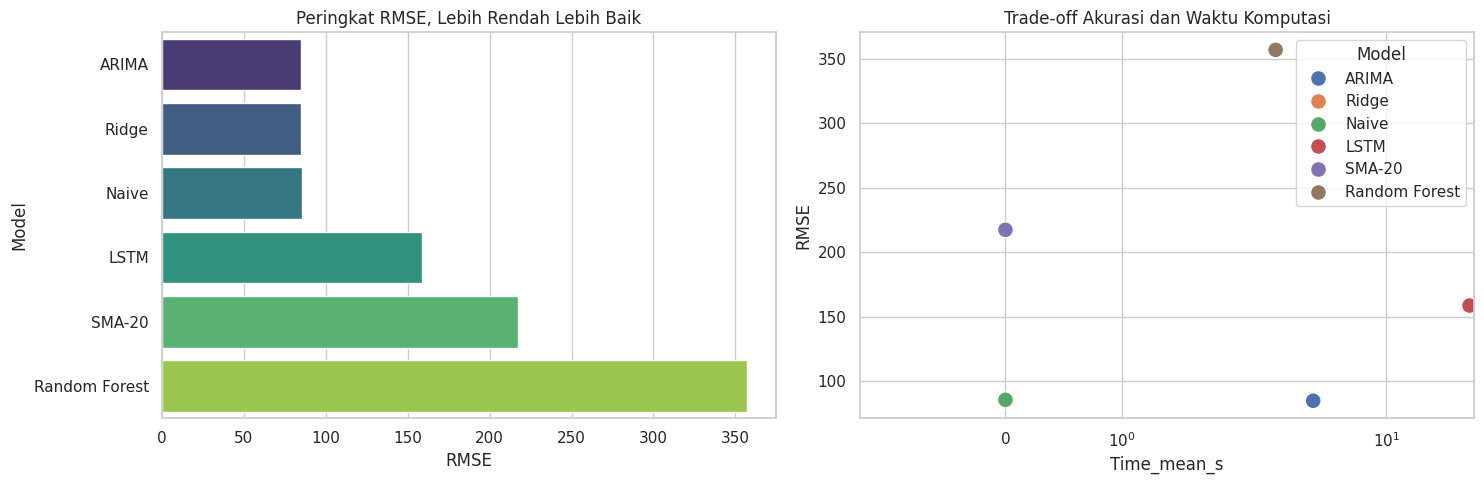

In [13]:
metric_rows = []
for model, g in aligned.groupby("Model"):
    err = g.Actual - g.Prediction
    metric_rows.append({"Model": model, "N": len(g), "MAE": np.abs(err).mean(),
                        "RMSE": np.sqrt(np.mean(err**2)), "MAPE_pct": np.mean(np.abs(err/g.Actual))*100})
benchmark = pd.DataFrame(metric_rows)

seed_metrics = metric_frame(all_long[all_long.Date.isin(common_dates)])
stability = seed_metrics.groupby("Model").RMSE.agg([("RMSE_SD", "std"), ("Runs", "count")]).reset_index()
stability["RMSE_SD"] = stability.RMSE_SD.fillna(0)
time_df = pd.DataFrame(timing).groupby("Model", as_index=False).Seconds.agg([("Time_mean_s", "mean")]).reset_index()
benchmark = benchmark.merge(stability, on="Model", how="left").merge(time_df, on="Model", how="left")
benchmark["Rank_RMSE"] = benchmark.RMSE.rank(method="min").astype(int)
benchmark = benchmark.sort_values(["RMSE", "MAE"]).reset_index(drop=True)

display(benchmark.style.format({"MAE":"{:,.2f}", "RMSE":"{:,.2f}", "MAPE_pct":"{:.3f}", "RMSE_SD":"{:,.3f}", "Time_mean_s":"{:,.2f}"}).background_gradient(subset=["RMSE"], cmap="RdYlGn_r").set_caption("Benchmark Card IHSG, Window Uji 2025"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=benchmark, x="RMSE", y="Model", hue="Model", legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Peringkat RMSE, Lebih Rendah Lebih Baik")
sns.scatterplot(data=benchmark, x="Time_mean_s", y="RMSE", hue="Model", s=130, ax=axes[1])
axes[1].set_title("Trade-off Akurasi dan Waktu Komputasi"); axes[1].set_xscale("symlog")
plt.tight_layout(); plt.show()

## 14. Visual Prediksi dan Diagnostik Error

Grafik pertama membandingkan prediksi pada tanggal yang sama. Grafik kedua menilai distribusi error. Error yang sempit dan berpusat dekat nol lebih baik, tetapi keputusan tetap harus mempertimbangkan stabilitas dan waktu komputasi.

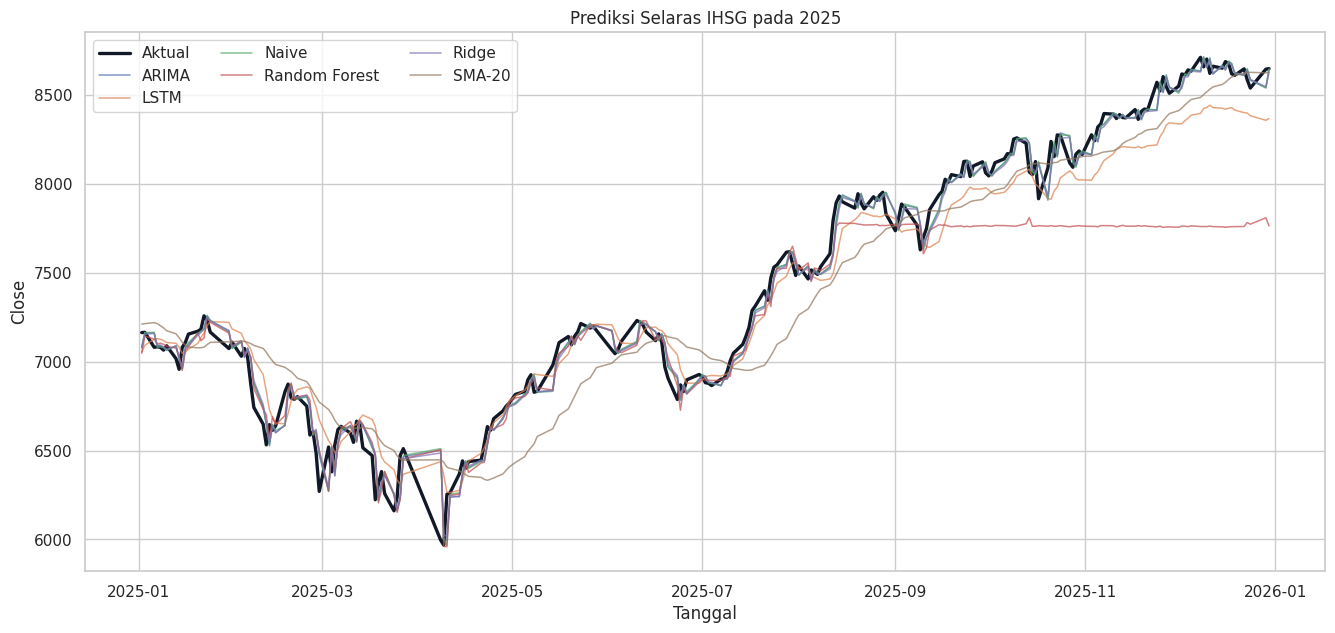

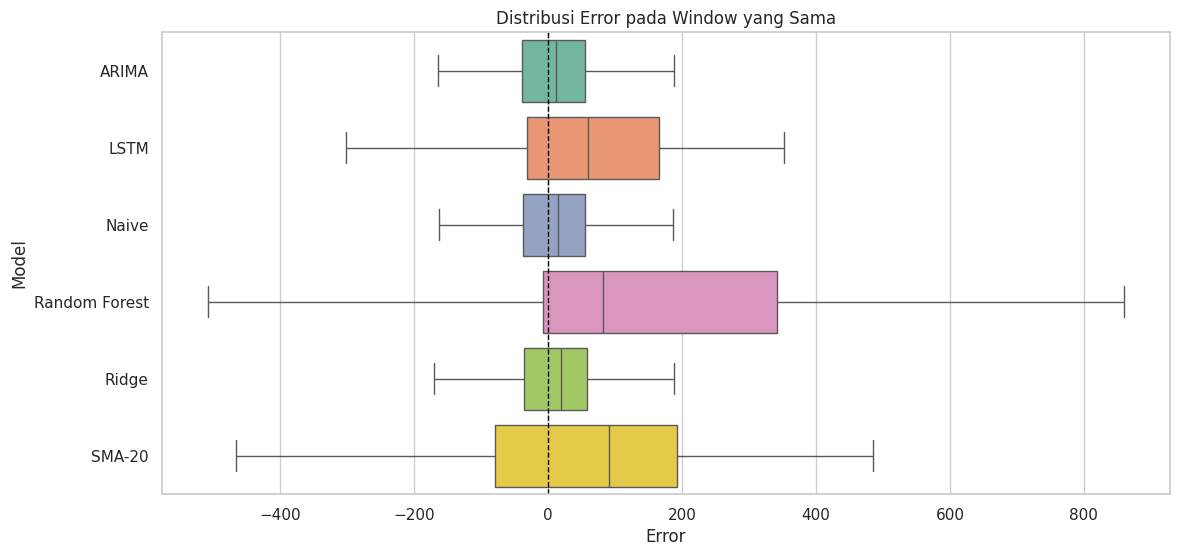

In [14]:
actual_series = aligned.drop_duplicates("Date").sort_values("Date")
plt.figure(figsize=(16, 7))
plt.plot(actual_series.Date, actual_series.Actual, color="#111827", lw=2.4, label="Aktual")
for model, g in aligned.groupby("Model"):
    g = g.sort_values("Date")
    plt.plot(g.Date, g.Prediction, lw=1.1, alpha=.72, label=model)
plt.title("Prediksi Selaras IHSG pada 2025"); plt.xlabel("Tanggal"); plt.ylabel("Close"); plt.legend(ncol=3); plt.show()

errors = aligned.assign(Error=lambda x: x.Actual-x.Prediction)
plt.figure(figsize=(13, 6))
sns.boxplot(data=errors, x="Error", y="Model", hue="Model", legend=False, palette="Set2", showfliers=False)
plt.axvline(0, color="black", ls="--", lw=1)
plt.title("Distribusi Error pada Window yang Sama"); plt.show()

## 15. Analisis Logis dan Critical Thinking

Kinerja terbaik tidak boleh ditetapkan hanya dari satu angka. Notebook mengevaluasi lima aspek:

- **Keadilan:** seluruh model menghadapi tanggal aktual 2025 yang sama.
- **Akurasi:** RMSE menjadi metrik peringkat utama, lalu MAE dan MAPE sebagai pemeriksaan silang.
- **Stabilitas:** LSTM dinilai lintas seed. Variasi tinggi menurunkan kepercayaan terhadap satu hasil terbaik.
- **Efisiensi:** peningkatan kecil perlu dibandingkan dengan tambahan waktu komputasi.
- **Kesederhanaan:** jika ARIMA atau Naive memiliki galat yang hampir sama dengan LSTM, model sederhana dapat lebih layak karena mudah diaudit dan dijalankan ulang.

Harga indeks bersifat nonstasioner dan sulit diprediksi. MAPE harga yang rendah belum otomatis berarti strategi investasi menguntungkan. Evaluasi ekonomi memerlukan prediksi return, arah, biaya transaksi, dan pengujian di beberapa rezim pasar.

In [15]:
best = benchmark.iloc[0]
naive_rmse = float(benchmark.loc[benchmark.Model=="Naive", "RMSE"].iloc[0])
improvement = (naive_rmse-best.RMSE)/naive_rmse*100

analysis_table = pd.DataFrame({
    "Pertanyaan kritis": [
        "Model RMSE terbaik", "Peningkatan atas Naive", "Apakah periode setara?",
        "Apakah satu seed cukup?", "Risiko interpretasi utama"
    ],
    "Jawaban berbasis hasil": [
        f"{best.Model} dengan RMSE {best.RMSE:,.2f}", f"{improvement:.2f}%",
        "Ya, setelah alignment seluruh model memakai tanggal bersama 2025",
        "Tidak. LSTM dinilai dengan beberapa seed dan dilaporkan variasinya",
        "Akurasi harga tidak sama dengan profit investasi"
    ]
})
display(analysis_table.style.set_caption("Analisis Kritis Otomatis"))

,Pertanyaan kritis,Jawaban berbasis hasil
0,Model RMSE terbaik,ARIMA dengan RMSE 84.70
1,Peningkatan atas Naive,0.82%
2,Apakah periode setara?,"Ya, setelah alignment seluruh model memakai tanggal bersama 2025"
3,Apakah satu seed cukup?,Tidak. LSTM dinilai dengan beberapa seed dan dilaporkan variasinya
4,Risiko interpretasi utama,Akurasi harga tidak sama dengan profit investasi


## 16. Error, Bug, dan Logika Penanganan

Notebook membedakan tiga kondisi yang sering tertukar:

1. **Data gagal diunduh.** Penyebabnya biasanya Internet Kaggle belum aktif.
   Solusinya ialah mengaktifkan Internet atau menggunakan CSV OHLCV.
2. **Tanggal akhir bukan 31 Desember.** Kondisi ini normal jika bursa tutup.
   Kelengkapan dinilai dari jumlah observasi dan cakupan hari perdagangan.
3. **Alignment gagal.** Kondisi ini merupakan kesalahan eksperimen. Notebook
   menolak benchmark jika tanggal, aktual, jumlah observasi, atau model tidak
   identik.

Validasi ini sengaja memakai pesan diagnosis yang spesifik. Program tidak
melanjutkan analisis ketika syarat pembandingan adil belum terpenuhi.


In [16]:
final_status = matrix_control.copy()
final_status["N_uji_setelah_alignment"] = len(common_dates)
final_status["Status akhir"] = "LOLOS"
final_status.loc[final_status.Model.str.contains("LSTM"), "Status akhir"] = np.where(
    benchmark.loc[benchmark.Model=="LSTM", "Runs"].iloc[0] >= 3, "LOLOS", "PERLU SEED TAMBAHAN")
display(final_status.style.set_caption("Matriks Kontrol Final"))

,Model,Train final,Validasi desain,Test,Target,Horizon,Normalisasi,Seed,Status awal,N_uji_setelah_alignment,Status akhir
0,Naive,Riwayat sebelum tiap target,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,NA,Sesuai protokol,236,LOLOS
1,SMA-20,Riwayat sebelum tiap target,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,NA,Sesuai protokol,236,LOLOS
2,ARIMA,s.d. 2024 + update aktual,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,NA,Sesuai protokol,236,LOLOS
3,Ridge,s.d. 2024,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,StandardScaler train final,42,Sesuai protokol,236,LOLOS
4,Random Forest,s.d. 2024,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,Tidak,42,Sesuai protokol,236,LOLOS
5,LSTM,s.d. 2024,2024,Tanggal perdagangan 2025 yang sama,Close t+1,1,MinMaxScaler train final,"[42, 123, 2025]",Sesuai protokol,236,LOLOS


## 17. Laporan Pertanggungjawaban Otomatis

Teks di bawah terbentuk dari hasil aktual notebook. Salin bagian ini ke laporan kelompok setelah seluruh sel berhasil dijalankan.

In [17]:
report = f"""
### Laporan Pertanggungjawaban

**Kesalahan awal.** Benchmark awal ditolak karena ARIMA diuji pada 2024, sedangkan LSTM diuji pada 2025. Perbedaan tren, volatilitas, jumlah hari perdagangan, dan kejadian eksternal membuat selisih kinerja tidak dapat diatribusikan secara sah kepada algoritma.

**Proses koreksi.** Enam model dilatih dengan informasi sebelum periode uji dan dievaluasi pada {len(common_dates)} tanggal perdagangan bersama sepanjang 2025. Target dikunci sebagai harga penutupan satu hari perdagangan ke depan. Alignment memverifikasi kesamaan tanggal, jumlah observasi, seri aktual, serta ketiadaan nilai prediksi yang hilang.

**Hasil evaluasi ulang.** Berdasarkan RMSE, model peringkat pertama adalah **{best.Model}** dengan RMSE **{best.RMSE:,.2f}**, MAE **{best.MAE:,.2f}**, dan MAPE **{best.MAPE_pct:.3f}%**. Perbaikannya terhadap Naive sebesar **{improvement:.2f}%**. Hasil ini berlaku khusus untuk protokol dan window 2025.

**Keterbatasan.** Pengujian hanya mencakup satu tahun dan satu indeks. LSTM memakai {len(LSTM_SEEDS)} seed. Model belum dinilai berdasarkan return, arah pasar, biaya transaksi, atau beberapa fold walk-forward.

**Dasar keputusan.** Model terbaik dipilih terutama berdasarkan RMSE, lalu diperiksa melalui MAE, MAPE, stabilitas seed, waktu komputasi, dan keunggulan terhadap baseline. Klaim terbaik tidak boleh diperluas ke periode lain tanpa pengujian tambahan.
"""
display(Markdown(report))


### Laporan Pertanggungjawaban

**Kesalahan awal.** Benchmark awal ditolak karena ARIMA diuji pada 2024, sedangkan LSTM diuji pada 2025. Perbedaan tren, volatilitas, jumlah hari perdagangan, dan kejadian eksternal membuat selisih kinerja tidak dapat diatribusikan secara sah kepada algoritma.

**Proses koreksi.** Enam model dilatih dengan informasi sebelum periode uji dan dievaluasi pada 236 tanggal perdagangan bersama sepanjang 2025. Target dikunci sebagai harga penutupan satu hari perdagangan ke depan. Alignment memverifikasi kesamaan tanggal, jumlah observasi, seri aktual, serta ketiadaan nilai prediksi yang hilang.

**Hasil evaluasi ulang.** Berdasarkan RMSE, model peringkat pertama adalah **ARIMA** dengan RMSE **84.70**, MAE **62.20**, dan MAPE **0.864%**. Perbaikannya terhadap Naive sebesar **0.82%**. Hasil ini berlaku khusus untuk protokol dan window 2025.

**Keterbatasan.** Pengujian hanya mencakup satu tahun dan satu indeks. LSTM memakai 3 seed. Model belum dinilai berdasarkan return, arah pasar, biaya transaksi, atau beberapa fold walk-forward.

**Dasar keputusan.** Model terbaik dipilih terutama berdasarkan RMSE, lalu diperiksa melalui MAE, MAPE, stabilitas seed, waktu komputasi, dan keunggulan terhadap baseline. Klaim terbaik tidak boleh diperluas ke periode lain tanpa pengujian tambahan.


## 18. Ekspor Hasil

Sel ini menyimpan prediksi selaras, Matriks Kontrol, Benchmark Card, dan laporan. File dapat diunduh dari panel **Output** Kaggle setelah notebook selesai dijalankan.

In [18]:
aligned.to_csv("prediksi_ihsg_2025_aligned.csv", index=False)
benchmark.to_csv("benchmark_card_ihsg_2025.csv", index=False)
final_status.to_csv("matriks_kontrol_ihsg_2025.csv", index=False)
with open("laporan_pertanggungjawaban_ihsg.md", "w", encoding="utf-8") as f:
    f.write(report)

exports = pd.DataFrame({
    "File": ["prediksi_ihsg_2025_aligned.csv", "benchmark_card_ihsg_2025.csv", "matriks_kontrol_ihsg_2025.csv", "laporan_pertanggungjawaban_ihsg.md"],
    "Isi": ["Aktual dan prediksi per tanggal", "Metrik dan peringkat", "Kepatuhan protokol", "Narasi hasil otomatis"]
})
display(exports.style.set_caption("Output Akhir yang Berhasil Diekspor"))

,File,Isi
0,prediksi_ihsg_2025_aligned.csv,Aktual dan prediksi per tanggal
1,benchmark_card_ihsg_2025.csv,Metrik dan peringkat
2,matriks_kontrol_ihsg_2025.csv,Kepatuhan protokol
3,laporan_pertanggungjawaban_ihsg.md,Narasi hasil otomatis


## Kesimpulan dan Cara Menjalankan

Notebook ini membandingkan enam model pada tanggal perdagangan 2025 yang sama.
Kelengkapan data tidak lagi dinilai berdasarkan keberadaan transaksi tepat pada
31 Desember. Audit memakai sedikitnya 180 observasi, tanggal akhir minimal
15 Desember 2025, urutan waktu, dan cakupan alignment minimal 95 persen.

Cara menjalankan di Kaggle:

1. Impor notebook melalui **File > Import Notebook**.
2. Aktifkan **Internet** pada **Notebook Options**.
3. Jika Yahoo Finance tidak dapat diakses, tambahkan CSV IHSG melalui
   **Add Input**, lalu isi `CSV_PATH`.
4. Jalankan **Run All**.
5. Periksa tabel audit sebelum membaca Benchmark Card.

Format minimal CSV ialah `Date, Open, High, Low, Close`. Kolom `Volume`
disarankan, tetapi program dapat mengisinya dengan nol bila tidak tersedia.
